Nerea Barrio Cabezas

# Selección de la mejor agrupación de validación cruzada

Repasamos los nombres con los que se guardaron las métricas en los modelos entrenados.

In [1]:
import joblib

# Carga uno de tus archivos
data = joblib.load("/home/jovyan/TFG/checkpoint_CV_agrupacion_func_PRG.joblib")

# Accedemos al primer escenario, primer embedding y vemos las claves de métricas
escenario_ejemplo = list(data.keys())[0]
emb_ejemplo = list(data[escenario_ejemplo].keys())[0]

print(f"Diccionario de resultados para {escenario_ejemplo} - {emb_ejemplo}:")
print(list(data[escenario_ejemplo][emb_ejemplo].keys()))

Diccionario de resultados para C1 - single_embeddings:
['pooling_name', 'cv_roc_auc', 'cv_pr_auc', 'cv_lift', 'cv_auprg', 'cv_expected_f1g', 'cv_bal_accuracy_50', 'cv_mcc_50', 'cv_precision_50', 'cv_recall_50', 'cv_pr_gain_50', 'cv_f1g_50', 'cv_bal_accuracy_opt', 'cv_mcc_opt', 'cv_precision_opt', 'cv_recall_opt', 'cv_pr_gain_opt', 'cv_f1g_opt', 'cv_best_threshold', 'n_valid_folds', 'opt_time', 'estimators', 'fold_details']


Guardamos las métricas de los mejores en un DataFrame

In [3]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Diccionario con las rutas a tus archivos
archivos = {
    "Funcional": "/home/jovyan/TFG/checkpoint_CV_agrupacion_func_PRG.joblib",
    #"K-means sin EspS y NleK": "/home/jovyan/TFG/CV_Kmeans/checkpoint_CV_kmeans_PRG.joblib",
    "K-means": "/home/jovyan/TFG/CV_Kmeans/checkpoint_CV_kmeans_PRG_con_EspS_NleK.joblib",
    #"Sin Agrupar sin EspS y NleK": "/home/jovyan/TFG/CV_sin_agrupar/checkpoint_CV_sin_agrupar_PRG_sin_EspS_NleK.joblib",
    "Sin Agrupar": "/home/jovyan/TFG/CV_sin_agrupar/checkpoint_CV_sin_agrupar_PRG_con_EspS_NleK.joblib",
}

filas_lista = []

for nombre_agrupacion, ruta in archivos.items():
    try:
        data = joblib.load(ruta)

        for escenario, embs in data.items():
            # Cambiamos las variables de control para enfocarnos en la media del AUPRG
            mejor_promedio_auprg_escenario = -1.0
            mejor_fila_escenario = None

            for emb_name, res in embs.items():
                # Calculamos el promedio del AUPRG a lo largo de todos los folds para cada pooling
                auprg_means = []
                for folds_auprg in res["cv_auprg"]:
                    # np.atleast_1d previene errores si algún fold viniera como escalar
                    auprg_means.append(np.mean(np.atleast_1d(folds_auprg)))

                # Sustituimos nulos por un valor mínimo de control
                auprg_means = np.nan_to_num(auprg_means, nan=-1.0)

                # Buscamos el índice de la configuración que maximiza el rendimiento promedio
                idx = np.argmax(auprg_means)
                valor_actual_promedio = auprg_means[idx]

                # Si esta combinación es la mejor para el escenario actual, actualizamos la información
                if valor_actual_promedio > mejor_promedio_auprg_escenario:
                    mejor_promedio_auprg_escenario = valor_actual_promedio
                    mejor_fila_escenario = {
                        "Agrupación": nombre_agrupacion,
                        "Escenario": escenario,
                        "Bal. Acc. 50": res["cv_bal_accuracy_50"][idx],
                        "Bal. Acc. Opt": res["cv_bal_accuracy_opt"][idx],
                        "ROC AUC": res["cv_roc_auc"][idx],
                        "PR AUC": res["cv_pr_auc"][idx],
                        #"Lift": res["cv_lift"][idx],
                        "AUPRG": res["cv_auprg"][
                            idx
                        ],  # Mantenemos el array intacto para poder graficar o calcular tests
                        "F1 Gain": res["cv_f1g_opt"][idx],
                    }

            if mejor_fila_escenario:
                filas_lista.append(mejor_fila_escenario)

    except FileNotFoundError:
        print(f"Advertencia: No se encontró el archivo en {ruta}")

# Creamos el DataFrame maestro optimizado rigurosamente por AUPRG
df_final = pd.DataFrame(filas_lista)

# Mostramos la tabla para verificar la consolidación
display(df_final)

,Agrupación,Escenario,Bal. Acc. 50,Bal. Acc. Opt,ROC AUC,PR AUC,AUPRG,F1 Gain
0,Funcional,C1,0.856835,0.894044,0.909314,0.858959,0.897572,0.910321
1,Funcional,C2E,0.475631,0.511778,0.464481,0.545944,0.336379,0.501083
2,Funcional,C2P,0.785806,0.878735,0.885779,0.836197,0.799030,0.877731
3,Funcional,C3,0.580939,0.629325,0.626024,0.630194,0.302111,0.579398
4,K-means,C1,0.869686,0.870368,0.930251,0.815657,0.951176,0.933701
5,K-means,C2E,0.653186,0.749337,0.724800,0.508601,0.454080,0.710983
6,K-means,C2P,0.648685,0.707333,0.726576,0.459600,0.534795,0.742058
7,K-means,C3,0.548006,0.700418,0.611943,0.447164,0.389119,0.664815
8,Sin Agrupar,C1,0.857778,0.873758,0.923525,0.823963,0.944394,0.930673
9,Sin Agrupar,C2E,0.646002,0.727753,0.713077,0.588319,0.534580,0.642291


In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================================
# 1. Configuración de tus archivos CSV (Modifica las rutas si varían)
# =====================================================================
archivos = {
    "Funcional": {
        "all_scenarios": "results_NestedCV_Cx/results_NestedCV_nivel_estricto_g13sep/cv_results_all_scenarios_g13sep_estricto_PRG.csv",
        "per_fold": "results_NestedCV_Cx/results_NestedCV_nivel_estricto_g13sep/cv_results_per_fold_g13sep_estricto_PRG.csv"
    },
    "K-means": {
        "all_scenarios": "CV_Kmeans/results/results_NestedCV_nivel_estricto/cv_results_all_scenarios_estricto_kmeans_PRG_con_EspS_NleK.csv",      # <-- Tu ruta real
        "per_fold": "CV_Kmeans/results/results_NestedCV_nivel_estricto/cv_results_per_fold_estricto_kmeans_PRG_con_EspS_NleK.csv"                  # <-- Tu ruta real
    },
    "Sin Agrupar": {
        "all_scenarios": "CV_sin_agrupar/results/results_NestedCV_nivel_estricto_g13sep/cv_results_all_scenarios_sin_agrupar_estricto_PRG_con_EspS_NleK.csv",  # <-- Tu ruta real
        "per_fold": "CV_sin_agrupar/results/results_NestedCV_nivel_estricto_g13sep/cv_results_per_fold_sin_agrupar_estricto_PRG_con_EspS_NleK.csv" 
    }
}

dfs_to_concat = []

# Definimos las columnas que queremos conservar de tus archivos CSV
columnas_metricas = ['scenario', 'bal_accuracy_50', 'bal_accuracy_opt', 'roc_auc', 'pr_auc', 'auprg', 'expected_f1g']

for nombre_agrupacion, rutas in archivos.items():
    try:
        # A) Leemos el archivo global resumen de la agrupación
        df_all = pd.read_csv(rutas["all_scenarios"])
        
        # Encontramos la configuración que maximiza el AUPRG en cada escenario
        idx_mejores = df_all.groupby('scenario')['auprg'].idxmax()
        mejores_configs = df_all.loc[idx_mejores]
        
        # B) Si es Funcional o K-means, extraemos los folds desglosados del archivo per_fold
        if "per_fold" in rutas:
            df_folds = pd.read_csv(rutas["per_fold"])
            
            for _, config in mejores_configs.iterrows():
                # Filtramos los folds de la combinación exacta que resultó ser la mejor
                sub_df = df_folds[
                    (df_folds['scenario'] == config['scenario']) & 
                    (df_folds['representation'] == config['representation']) & 
                    (df_folds['pooling'] == config['pooling'])
                ].copy()
                
                sub_df['Agrupación'] = nombre_agrupacion
                # MODIFICACIÓN MÍNIMA: Guardamos todas las métricas en la lista
                dfs_to_concat.append(sub_df[['Agrupación'] + columnas_metricas])
                
        # C) Si es "Sin Agrupar", tomamos directamente los puntos globales (sin varianza)
        else:
            sub_df = mejores_configs.copy()
            sub_df['Agrupación'] = nombre_agrupacion
            # MODIFICACIÓN MÍNIMA: Guardamos todas las métricas en la lista
            dfs_to_concat.append(sub_df[['Agrupación'] + columnas_metricas])
            
    except FileNotFoundError:
        print(f"Nota: No se procesó '{nombre_agrupacion}' porque falta algún archivo.")

# Unificamos todos los datos en el DataFrame final para Seaborn
df_final = pd.concat(dfs_to_concat, ignore_index=True)

# MODIFICACIÓN MÍNIMA: Renombramos todas las columnas a su formato académico original
df_final.rename(columns={
    'scenario': 'Escenario', 
    'auprg': 'AUPRG',
    'bal_accuracy_50': 'Bal. Acc. 50',
    'bal_accuracy_opt': 'Bal. Acc. Opt',
    'roc_auc': 'ROC AUC',
    'pr_auc': 'PR AUC',
    'expected_f1g': 'F1 Gain'
}, inplace=True)

# Forzamos el orden académico estricto en el eje X
df_final['Escenario'] = pd.Categorical(
    df_final['Escenario'], 
    categories=["C1", "C2E", "C2P", "C3"], 
    ordered=True
)

print(f"¡Procesamiento completado con éxito! Filas totales cargadas: {len(df_final)}")


¡Procesamiento completado con éxito! Filas totales cargadas: 1213


In [46]:
# Comprobación de filas, medias y desviaciones estándar reales por escenario
auditoria = df_final.groupby(["Agrupación", "Escenario"], observed=False)["AUPRG"].agg(
    Folds_Reales="count",
    Media_Pintada="mean",
    Desviacion_Estandar="std"
).reset_index()

display(auditoria)

,Agrupación,Escenario,Folds_Reales,Media_Pintada,Desviacion_Estandar
0,Funcional,C1,5,0.897580,0.074203
1,Funcional,C2E,3,0.336367,0.283421
2,Funcional,C2P,5,0.799020,0.169095
3,Funcional,C3,5,0.302120,0.175848
4,K-means,C1,5,0.951160,0.020182
5,K-means,C2E,7,0.454086,0.343997
6,K-means,C2P,5,0.534800,0.359077
7,K-means,C3,15,0.389133,0.267323
8,Sin Agrupar,C1,5,0.944380,0.032263
9,Sin Agrupar,C2E,24,0.534579,0.373271


In [49]:
# =====================================================================
# EL TRUCO LIMPIO: Inyectamos el punto C3 con TODAS las métricas
# =====================================================================
try:
    # Leemos el archivo global de Sin Agrupar para extraer la fila real de C3
    df_sa_all = pd.read_csv(archivos["Sin Agrupar"]["all_scenarios"])
    
    # Filtramos la fila exacta de C3
    fila_c3_orig = df_sa_all[df_sa_all['scenario'] == 'C3']
    
    if not fila_c3_orig.empty:
        # Extraemos los valores numéricos correspondientes uno a uno
        valor_auprg = float(fila_c3_orig['auprg'].max())
        valor_roc = float(fila_c3_orig['roc_auc'].max())
        valor_pr = float(fila_c3_orig['pr_auc'].max())
        valor_acc_50 = float(fila_c3_orig['bal_accuracy_50'].max())
        valor_acc_opt = float(fila_c3_orig['bal_accuracy_opt'].max())
        
        # Control para el nombre del F1 (por si acaso en este CSV cambia)
        col_f1 = 'expected_f1_gain' if 'expected_f1_gain' in fila_c3_orig.columns else 'expected_f1g'
        valor_f1 = float(fila_c3_orig[col_f1].max())
        
        # Creamos la fila unificada con los nombres ya mapeados al formato final del DataFrame
        fila_c3_completa = pd.DataFrame([{
            "Agrupación": "Sin Agrupar", 
            "Escenario": "C3", 
            "AUPRG": valor_auprg,
            "ROC AUC": valor_roc,
            "PR AUC": valor_pr,
            "Bal. Acc. 50": valor_acc_50,
            "Bal. Acc. Opt": valor_acc_opt,
            "F1 Gain": valor_f1
        }])
        
        # Se la acoplamos a tu df_final original sin alterar tus bucles de arriba
        df_final = pd.concat([df_final, fila_c3_completa], ignore_index=True)
        
        # Refrescamos el orden categórico del eje X para que no se altere el dibujo
        df_final['Escenario'] = pd.Categorical(
            df_final['Escenario'], 
            categories=["C1", "C2E", "C2P", "C3"], 
            ordered=True
        )
except Exception as e:
    print(f"Aviso: No se pudo inyectar el punto C3 completo de Sin Agrupar. Error: {e}")

Lo representamos en una gráfica.

/tmp/ipykernel_608/2468858637.py:15: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  g = sns.catplot(


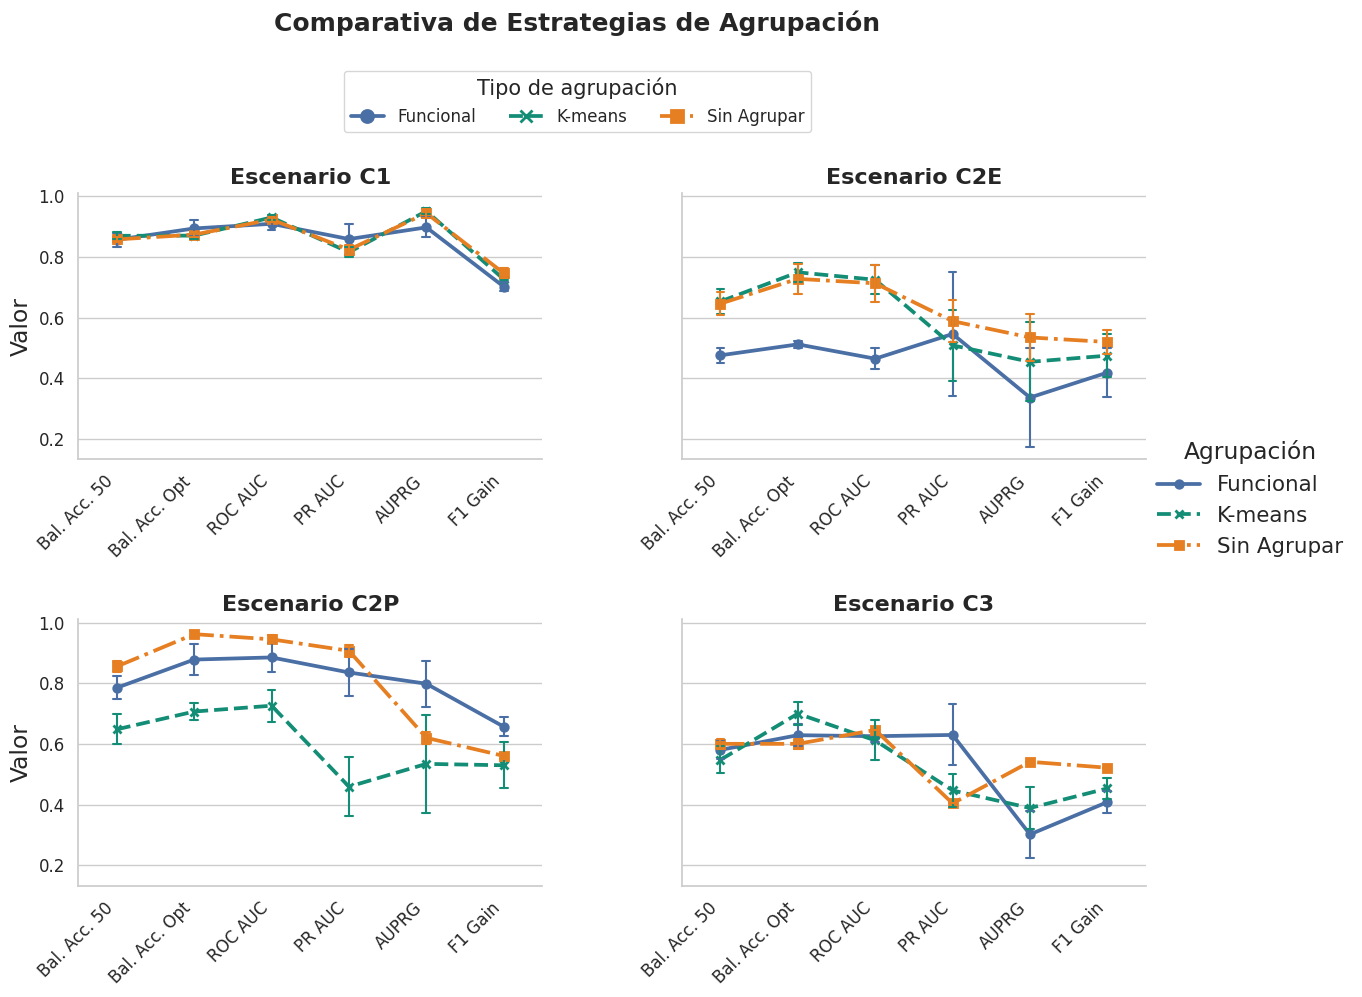

In [50]:
# Convertimos a formato "largo" para Seaborn
df_melted = df_final.melt(id_vars=["Agrupación", "Escenario"], 
                          var_name="Métrica", 
                          value_name="Valor")

df_sin_lift = df_melted[df_melted["Métrica"] != "Lift"]
#df_solo_lift = df_final[["Agrupación", "Escenario", "Lift"]]

# Configuración estética
sns.set_theme(style="whitegrid", font_scale=1.4)
plt.rcParams['font.family'] = 'sans-serif'
colores = {"Funcional": "#4A6FA5", "K-means": "#138D75", "Sin Agrupar": "#E67E22"}

# Crear el gráfico de paneles (FacetGrid)
g = sns.catplot(
    data=df_sin_lift, 
    x="Métrica", y="Valor", hue="Agrupación", 
    col="Escenario",
    col_order=["C1", "C2E", "C2P", "C3"],
    col_wrap=2,
    kind="point", 
    height=5, 
    aspect=1.2,
    palette=colores,
    markers=["o", "x", "s"],
    linestyles=["-", "--", "-."],
    capsize=0.1,
    err_kws={"linewidth": 1.5, "zorder": 3},
    scale=1,
    sharex=False,
    errorbar="se"       
)

# 3. Iterar por cada panel para añadir el texto del Lift
for ax in g.axes.flat:
    # # Obtener el nombre del escenario de este panel
    # escenario_actual = ax.get_title().split(" = ")[-1]
    
    # # Filtrar el lift solo para este escenario
    # lifts_escenario = df_solo_lift[df_solo_lift["Escenario"] == escenario_actual]
    
    # # Construir el texto informativo
    # texto_lift = "LIFT:\n"
    # for _, row in lifts_escenario.iterrows():
    #     # Abreviamos el nombre de la agrupación para que quepa bien
    #     nombre_abr = row['Agrupación'].split(' ')[0] 
    #     texto_lift += f"• {nombre_abr}: {row['Lift']:.2f}\n"
    
    # # Añadir el cuadro de texto en una esquina (puedes probar 'upper left' o 'lower right')
    # ax.text(0.05, 0.05, texto_lift.strip(), transform=ax.transAxes, 
    #         fontsize=9, verticalalignment='bottom', 
    #         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

    # Configuración de ejes
    ax.tick_params(labelbottom=True, labelsize=12)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
    #ax.axhline(0.5, ls='--', color='gray', alpha=0.3)
    ax.set_xlabel("")
    
# Refinar ejes y títulos
g.set_axis_labels("", "Valor")
g.set_titles("Escenario {col_name}", weight='bold', size=16)
# g.set(ylim=(0, 1.05))

# # Rotar etiquetas X para que se lean bien todas las métricas
# for ax in g.axes.flat:
#     ax.tick_params(axis='x', rotation=45)
#     ax.axhline(0.5, ls='--', color='gray', alpha=0.3) # Línea de referencia azar

# Título general y leyenda debajo
plt.subplots_adjust(top=0.78, hspace=0.6, wspace=0.3)
g.fig.text(0.44, 0.95, 'Comparativa de Estrategias de Agrupación', 
           fontsize=18, weight='bold', ha='center', va='center')

# sns.move_legend(g, loc="upper center", bbox_to_anchor=(0.5, 0.93), ncol=2, title="Tipo de Agrupamiento", frameon=True)

handles, labels = ax.get_legend_handles_labels()
g.fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.44, 0.91), 
             ncol=3, title="Tipo de agrupación", frameon=True, 
             fontsize=12, title_fontsize=15, markerscale=1.6)
plt.savefig("resumen_metricas_agrupaciones.png", dpi=300, bbox_inches='tight')
plt.show()

Ahora dibujamos solo el pr auc gain para cada subnivel y tipo de agrupación.

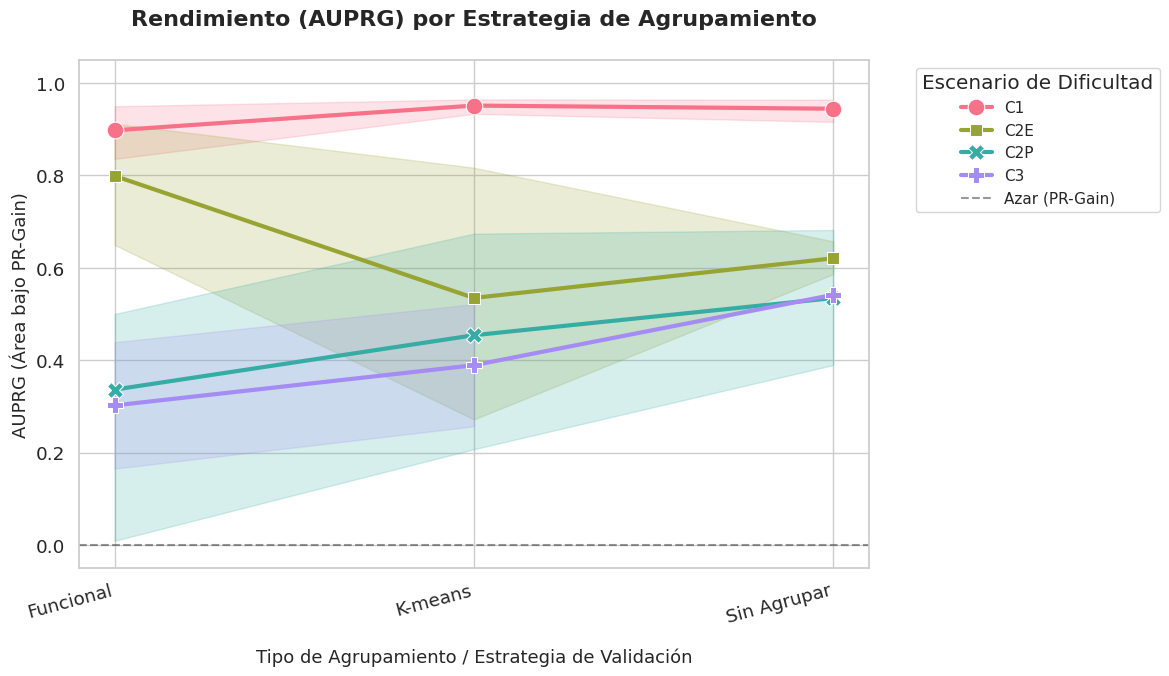

In [34]:
# 1. Filtrar los datos para AUPRG
df_auprg = df_final[["Agrupación", "Escenario", "AUPRG"]]

# 2. Configuración estética
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(12, 7))

# 3. Crear la gráfica de líneas
# Agrupación en el eje X, AUPRG en el eje Y, y una línea por Escenario
ax = sns.lineplot(
    data=df_auprg, 
    x="Agrupación", 
    y="AUPRG", 
    hue="Escenario", 
    style="Escenario", 
    markers=True, 
    dashes=False, 
    markersize=12, 
    linewidth=3,
    palette="husl", 
    hue_order=["C1", "C2E", "C2P", "C3"] # Forzamos el orden de leyenda
)

# 4. Personalización del gráfico
plt.title("Rendimiento (AUPRG) por Estrategia de Agrupamiento", fontsize=16, weight='bold', pad=25)
plt.xlabel("Tipo de Agrupamiento / Estrategia de Validación", fontsize=13, labelpad=15)
plt.ylabel("AUPRG (Área bajo PR-Gain)", fontsize=13)
plt.ylim(-0.05, 1.05) # Empezamos un poco por debajo de 0 para ver bien la línea de azar

# Rotamos las etiquetas del eje X si son muy largas
plt.xticks(rotation=15, ha='right')

# Línea de referencia en 0.0 (Azar en PR-Gain)
plt.axhline(0.0, ls='--', color='black', alpha=0.4, label="Azar (PR-Gain)")

# Ajustar leyenda
plt.legend(title="Escenario de Dificultad", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig("resumen_auprg_agrupaciones.png", dpi=300)
plt.show()

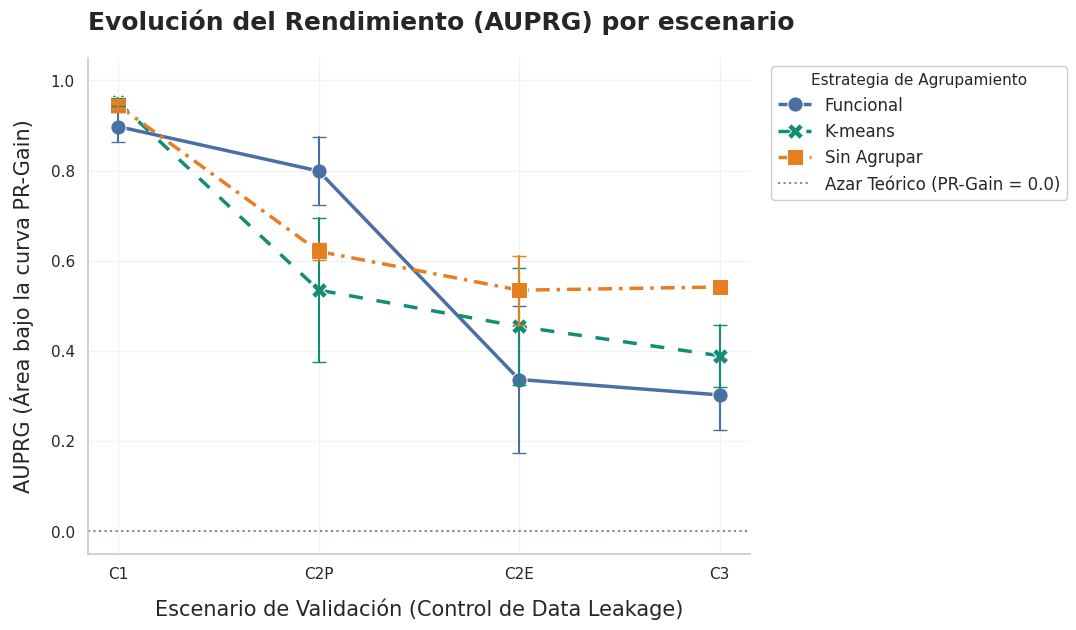

In [35]:
# 1. Asegurar la estructura correcta de los datos
# Nota: Si tu DataFrame tiene los escenarios ordenados al revés, con esto se soluciona
df_auprg = df_final[["Agrupación", "Escenario", "AUPRG"]].copy()
df_auprg['Escenario'] = pd.Categorical(
    df_auprg['Escenario'], 
    categories=["C1", "C2P", "C2E", "C3"], 
    ordered=True
)

# 2. Configuración estética global (Estilo académico)
sns.set_theme(style="whitegrid", rc={"grid.color": "#F0F3F4", "grid.linestyle": "-"}, font_scale=1.1)
plt.rcParams["font.family"] = "sans-serif"
plt.figure(figsize=(11, 6.5))

# 3. Definir mapeos fijos para control total del diseño
# Cambiamos el eje X para que sea el Escenario, mostrando la evolución del leakage
colores = {"Funcional": "#4A6FA5", "K-means": "#138D75", "Sin Agrupar": "#E67E22"}
marcadores = {"Funcional": "o", "K-means": "X", "Sin Agrupar": "s"}
lineas = {
    "Funcional": (1, 0),        # Línea continua
    "K-means": (4, 4),          # Línea discontinua (dash)
    "Sin Agrupar": (4, 2, 1, 2) # Línea punto-guion (dash-dot)
}

# 4. Crear la gráfica de líneas refinada
ax = sns.lineplot(
    data=df_auprg,
    x="Escenario",
    y="AUPRG",
    hue="Agrupación",
    style="Agrupación",
    markers=marcadores,
    dashes=lineas,
    markersize=11,
    linewidth=2.5,
    palette=colores,
    hue_order=["Funcional", "K-means", "Sin Agrupar"],
    errorbar="se",        
    err_style="bars",           
    err_kws={"capsize": 5, "linewidth": 1.5, "zorder": 3},
)

# 5. Personalización avanzada de ejes y etiquetas
plt.title(
    "Evolución del Rendimiento (AUPRG) por escenario",
    fontsize=18,
    weight="bold",
    pad=20,
    loc="left",
)
plt.xlabel("Escenario de Validación (Control de Data Leakage)", fontsize=15, labelpad=12)
plt.ylabel("AUPRG (Área bajo la curva PR-Gain)", fontsize=15, labelpad=12)
plt.tick_params(axis="both", labelsize=11)

# Ajuste estricto de límites del eje Y (0 a 1 para métricas probabilísticas)
plt.ylim(-0.05, 1.05)

# 6. Línea de referencia horizontal impecable para el AZAR
plt.axhline(
    0.0,
    ls=":",
    color="#7F8C8D",
    linewidth=1.5,
    zorder=1,
    label="Azar Teórico (PR-Gain = 0.0)",
)

# 7. Ajustes de la Leyenda (Limpia y fuera del gráfico para que no tape nada)
# Unificamos las leyendas de color y estilo automáticamente usando Matplotlib
handles, labels = ax.get_legend_handles_labels()
plt.legend(
    handles=handles,
    labels=labels,
    title="Estrategia de Agrupamiento",
    title_fontsize=11,
    fontsize=12,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    shadow=False,
    facecolor="white",
    edgecolor="#BDC3C7",
)

# Eliminar bordes innecesarios (Top y Right)
sns.despine(left=False, bottom=False)

# Optimizar distribución de espacios y guardar en alta resolución
plt.tight_layout()
plt.savefig("resumen_auprg_agrupaciones_profesional.png", dpi=300)
plt.show()

## Selección del mejor modelo

Repetimos el mismo proceso de antes pero con modelos en vez de tipos de agrupación. Se probarán la regresión logística, la regresión logística + fine-tuning, el Random Forest y el perceptrón multicapa.

Necesitamos especificarle cuál era la clase WarmStartLogisticRegresion para que sepa interpretar el .joblib procedente del fine-tuning.

In [36]:
from sklearn.linear_model import LogisticRegression

class WarmStartLogisticRegression(LogisticRegression):
    """
    LogisticRegression con inicialización desde pesos externos.

    El truco clave: almacenar init_coef e init_intercept como parámetros del
    constructor hace que get_params() los incluya, y por tanto clone() los
    preserve cuando GridSearchCV crea copias del estimador para cada fold
    y combinación de hiperparámetros. Sin esto, los pesos se perderían en
    cada clonado (Buitinck et al., 2013, ECML PKDD; sklearn dev docs).

    Con warm_start=True, sklearn usa coef_ e intercept_ existentes como
    punto de partida del optimizador en la siguiente llamada a fit().
    Asignarlos en fit() (justo antes de llamar al super()) garantiza que
    cada fold del CV parte siempre de los mismos pesos del modelo origen,
    sin que los folds anteriores contaminen la inicialización.

    :param init_coef:      np.ndarray shape (1, n_features) o None.
    :param init_intercept: np.ndarray shape (1,) o None.
    :param lr_kwargs:      Argumentos estándar de LogisticRegression
                           (C, penalty, solver, max_iter, tol, …).
    """

    def __init__(self, C=1.0, penalty='l2', solver='lbfgs', max_iter=100, tol=1e-4, class_weight=None, init_coef=None, init_intercept=None, **lr_kwargs):
        self.init_coef      = init_coef
        self.init_intercept = init_intercept
        # warm_start=True se fuerza solo si hay pesos; si no, comportamiento normal
        if init_coef is not None:
            lr_kwargs["warm_start"] = True
        super().__init__(C=C, penalty=penalty, solver=solver, max_iter=max_iter, tol=tol, class_weight=class_weight, **lr_kwargs)

    def fit(self, X, y, sample_weight=None):
        if self.init_coef is not None:
            # Asignar los pesos antes de fit() para que warm_start los use
            self.coef_      = self.init_coef.copy()
            self.intercept_ = self.init_intercept.copy()
            # classes_ es necesario para que sklearn no rechace coef_ pre-asignado
            self.classes_ = np.array([0, 1])
        return super().fit(X, y, sample_weight=sample_weight)

    def get_params(self, deep=True):
        """Incluye init_coef e init_intercept para que clone() los preserve."""
        params = super().get_params(deep=deep)
        params["init_coef"]      = self.init_coef
        params["init_intercept"] = self.init_intercept
        return params

Echamos un primer vistazo a la estructura de los datos.

In [60]:
import joblib

# Carga uno de tus archivos
data = joblib.load("/home/jovyan/TFG/CV_Kmeans_con_EspS_NleK_all_models/checkpoint_CV_kmeans_PRG_con_EspS_NleK_warmstart.joblib")

# Accedemos al primer escenario, primer embedding y vemos las claves de métricas
escenario_ejemplo = list(data.keys())[0]
emb_ejemplo = list(data[escenario_ejemplo].keys())[0]

print(f"Diccionario de resultados para {escenario_ejemplo} - {emb_ejemplo}:")
print(list(data[escenario_ejemplo][emb_ejemplo].keys()))

Diccionario de resultados para C1 - single_embeddings:
['pooling_name', 'cv_roc_auc', 'cv_pr_auc', 'cv_lift', 'cv_auprg', 'cv_expected_f1g', 'cv_bal_accuracy_50', 'cv_mcc_50', 'cv_precision_50', 'cv_recall_50', 'cv_pr_gain_50', 'cv_f1g_50', 'cv_bal_accuracy_opt', 'cv_mcc_opt', 'cv_precision_opt', 'cv_recall_opt', 'cv_pr_gain_opt', 'cv_f1g_opt', 'cv_best_threshold', 'n_valid_folds', 'opt_time', 'estimators', 'fold_details']


Guardamos las métricas de los mejores en un DataFrame.

In [61]:
import joblib
import numpy as np
import pandas as pd

archivos = {
    "Regresión Logística": "/home/jovyan/TFG/CV_Kmeans_con_EspS_NleK_all_models/checkpoint_CV_kmeans_PRG_con_EspS_NleK_reglog.joblib",
    "Regresión Logística + Fine-tuning": "/home/jovyan/TFG/CV_Kmeans_con_EspS_NleK_all_models/checkpoint_CV_kmeans_PRG_con_EspS_NleK_warmstart.joblib",
    "Random Forest": "/home/jovyan/TFG/CV_Kmeans_con_EspS_NleK_all_models/checkpoint_CV_kmeans_PRG_con_EspS_NleK_RandomForest.joblib",
    "Multilayer Perceptron": "/home/jovyan/TFG/CV_Kmeans_con_EspS_NleK_all_models/checkpoint_CV_kmeans_PRG_con_EspS_NleK_MLP.joblib",
}

filas_lista = []

for nombre_modelo, ruta in archivos.items():
    try:
        data = joblib.load(ruta)

        for escenario, embs in data.items():
            mejor_promedio_auprg_escenario = -1.0
            mejor_fila_escenario = None

            for emb_name, res in embs.items():
                # res["cv_auprg"] ya contiene la lista de medias directas de cada pooling
                auprg_means = np.nan_to_num(res["cv_auprg"], nan=-1.0)
                
                # Buscamos el índice del mejor pooling
                idx = np.argmax(auprg_means)
                valor_promedio_ganador = auprg_means[idx]

                if valor_promedio_ganador > mejor_promedio_auprg_escenario:
                    mejor_promedio_auprg_escenario = valor_promedio_ganador
                    
                    # ¡AQUÍ ESTÁ LA CLAVE! Extraemos el valor de AUPRG de cada uno de los folds reales
                    lista_folds_reales = [
                        fold["auprg"] for fold in res["fold_details"][idx] 
                        if "auprg" in fold and not np.isnan(fold["auprg"])
                    ]
                    
                    mejor_fila_escenario = {
                        "Modelo": nombre_modelo,
                        "Escenario": escenario,
                        "Bal. Acc. 50": res["cv_bal_accuracy_50"][idx],
                        "Bal. Acc. Opt": res["cv_bal_accuracy_opt"][idx],
                        "ROC AUC": res["cv_roc_auc"][idx],
                        "PR AUC": res["cv_pr_auc"][idx],
                        "AUPRG": valor_promedio_ganador, # Guardamos la media para control visual
                        "AUPRG_lista": lista_folds_reales,           # Guardamos los 15 folds puros para el test
                        "F1 Gain": res["cv_f1g_opt"][idx],
                        "Lift": res["cv_lift"][idx],
                    }

            if mejor_fila_escenario:
                filas_lista.append(mejor_fila_escenario)

    except FileNotFoundError:
        print(f"Advertencia: No se encontró el archivo en {ruta}")

# Reconstruimos el DataFrame maestro con los datos corregidos
df_final = pd.DataFrame(filas_lista)
display(df_final[["Modelo", "Escenario", "Bal. Acc. 50", "Bal. Acc. Opt", "ROC AUC", "PR AUC", "AUPRG", "F1 Gain", "Lift"]])

,Modelo,Escenario,Bal. Acc. 50,Bal. Acc. Opt,ROC AUC,PR AUC,AUPRG,F1 Gain,Lift
0,Regresión Logística,C1,0.869686,0.870368,0.930251,0.815657,0.951176,0.933701,3.943068
1,Regresión Logística,C2E,0.653186,0.749337,0.724800,0.508601,0.454080,0.710983,1.890470
2,Regresión Logística,C2P,0.648685,0.707333,0.726576,0.459600,0.534795,0.742058,2.115141
3,Regresión Logística,C3,0.548006,0.700418,0.611943,0.447164,0.389119,0.664815,1.786627
4,Regresión Logística + Fine-tuning,C1,0.869686,0.877639,0.930384,0.816444,0.951487,0.933648,3.946880
5,Regresión Logística + Fine-tuning,C2E,0.653598,0.749337,0.724845,0.508937,0.454501,0.710983,1.891614
6,Regresión Logística + Fine-tuning,C2P,0.648685,0.707333,0.726586,0.459838,0.534798,0.742058,2.116121
7,Regresión Logística + Fine-tuning,C3,0.548200,0.700804,0.612053,0.446723,0.386032,0.665047,1.780618
8,Random Forest,C1,0.746626,0.879841,0.936951,0.857220,0.970978,0.933543,4.144506
9,Random Forest,C2E,0.525245,0.671937,0.605575,0.472743,0.451213,0.710934,2.046506


In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================================
# 1. Configuración de tus archivos CSV (Modifica las rutas si varían)
# =====================================================================
archivos = {
    "Regresión Logística": {
        "all_scenarios": "CV_Kmeans/results/results_NestedCV_nivel_estricto/cv_results_all_scenarios_estricto_kmeans_PRG_con_EspS_NleK.csv",
        "per_fold": "CV_Kmeans/results/results_NestedCV_nivel_estricto/cv_results_per_fold_estricto_kmeans_PRG_con_EspS_NleK.csv"
    },
    "Regresión Logística + Fine-tuning": {
        "all_scenarios": "CV_Kmeans_con_EspS_NleK_all_models/results/cv_results_all_scenarios_estricto_kmeans_PRG_con_EspS_NleK_warmstart.csv",      # <-- Tu ruta real
        "per_fold": "CV_Kmeans_con_EspS_NleK_all_models/results/cv_results_per_fold_estricto_kmeans_PRG_con_EspS_NleK_warmstart.csv"                  # <-- Tu ruta real
    },
    "Random Forest": {
        "all_scenarios": "CV_Kmeans_con_EspS_NleK_all_models/results/cv_results_all_scenarios_estricto_kmeans_PRG_con_EspS_NleK_RandomForest.csv",  # <-- Tu ruta real
        "per_fold": "CV_Kmeans_con_EspS_NleK_all_models/results/cv_results_per_fold_estricto_kmeans_PRG_con_EspS_NleK_RandomForest.csv" 
    },
    "Multilayer Perceptron": {
        "all_scenarios": "CV_Kmeans_con_EspS_NleK_all_models/results/cv_results_all_scenarios_estricto_kmeans_PRG_con_EspS_NleK_MLP.csv",  # <-- Tu ruta real
        "per_fold": "CV_Kmeans_con_EspS_NleK_all_models/results/cv_results_per_fold_estricto_kmeans_PRG_con_EspS_NleK_MLP.csv" 
    }
}

dfs_to_concat = []

# Definimos las columnas que queremos conservar de tus archivos CSV
columnas_metricas = ['scenario', 'bal_accuracy_50', 'bal_accuracy_opt', 'roc_auc', 'pr_auc', 'auprg', 'expected_f1g']

for nombre_modelo, rutas in archivos.items():
    try:
        # A) Leemos el archivo global resumen de la agrupación
        df_all = pd.read_csv(rutas["all_scenarios"])
        
        # Encontramos la configuración que maximiza el AUPRG en cada escenario
        idx_mejores = df_all.groupby('scenario')['auprg'].idxmax()
        mejores_configs = df_all.loc[idx_mejores]
        
        # B) Si es Funcional o K-means, extraemos los folds desglosados del archivo per_fold
        if "per_fold" in rutas:
            df_folds = pd.read_csv(rutas["per_fold"])
            
            for _, config in mejores_configs.iterrows():
                # Filtramos los folds de la combinación exacta que resultó ser la mejor
                sub_df = df_folds[
                    (df_folds['scenario'] == config['scenario']) & 
                    (df_folds['representation'] == config['representation']) & 
                    (df_folds['pooling'] == config['pooling'])
                ].copy()
                
                sub_df['Modelo'] = nombre_modelo
                # MODIFICACIÓN MÍNIMA: Guardamos todas las métricas en la lista
                dfs_to_concat.append(sub_df[['Modelo'] + columnas_metricas])
                
        # C) Si es "Sin Agrupar", tomamos directamente los puntos globales (sin varianza)
        else:
            sub_df = mejores_configs.copy()
            sub_df['Modelo'] = nombre_modelo
            # MODIFICACIÓN MÍNIMA: Guardamos todas las métricas en la lista
            dfs_to_concat.append(sub_df[['Modelo'] + columnas_metricas])
            
    except FileNotFoundError:
        print(f"Nota: No se procesó '{nombre_modelo}' porque falta algún archivo.")

# Unificamos todos los datos en el DataFrame final para Seaborn
df_final = pd.concat(dfs_to_concat, ignore_index=True)

# MODIFICACIÓN MÍNIMA: Renombramos todas las columnas a su formato académico original
df_final.rename(columns={
    'scenario': 'Escenario', 
    'auprg': 'AUPRG',
    'bal_accuracy_50': 'Bal. Acc. 50',
    'bal_accuracy_opt': 'Bal. Acc. Opt',
    'roc_auc': 'ROC AUC',
    'pr_auc': 'PR AUC',
    'expected_f1g': 'F1 Gain'
}, inplace=True)

# Forzamos el orden académico estricto en el eje X
df_final['Escenario'] = pd.Categorical(
    df_final['Escenario'], 
    categories=["C1", "C2E", "C2P", "C3"], 
    ordered=True
)

print(f"¡Procesamiento completado con éxito! Filas totales cargadas: {len(df_final)}")

¡Procesamiento completado con éxito! Filas totales cargadas: 128


In [41]:
# Comprobación de filas, medias y desviaciones estándar reales por escenario
auditoria = df_final.groupby(["Modelo", "Escenario"], observed=False)["AUPRG"].agg(
    Folds_Reales="count",
    Media_Pintada="mean",
    Desviacion_Estandar="std"
).reset_index()

display(auditoria)

,Modelo,Escenario,Folds_Reales,Media_Pintada,Desviacion_Estandar
0,Multilayer Perceptron,C1,5,0.978580,0.005111
1,Multilayer Perceptron,C2E,7,0.562714,0.336688
2,Multilayer Perceptron,C2P,5,0.724900,0.144331
3,Multilayer Perceptron,C3,15,0.405987,0.296531
4,Random Forest,C1,5,0.970980,0.003735
5,Random Forest,C2E,7,0.451214,0.351846
6,Random Forest,C2P,5,0.706760,0.116370
7,Random Forest,C3,15,0.371833,0.288021
8,Regresión Logística,C1,5,0.951160,0.020182
9,Regresión Logística,C2E,7,0.454086,0.343997


Hacemos la representación gráfica.

/tmp/ipykernel_608/572031837.py:27: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  g = sns.catplot(


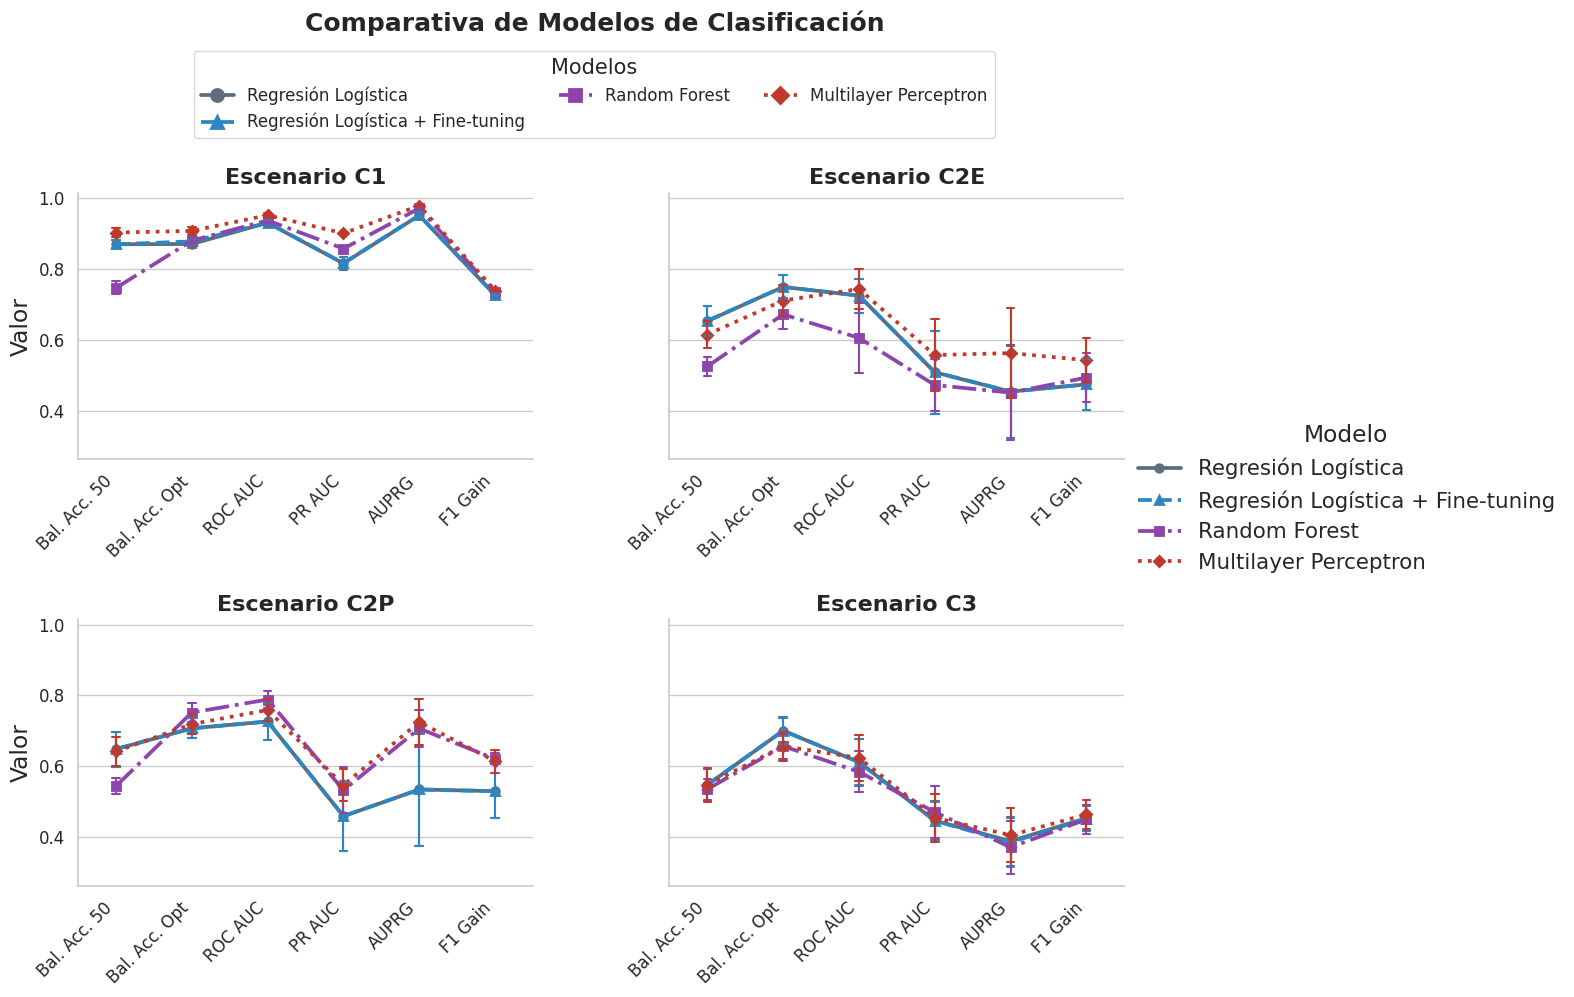

In [42]:
# Convertimos a formato "largo" para Seaborn
df_melted = df_final.melt(id_vars=["Modelo", "Escenario"], 
                          var_name="Métrica", 
                          value_name="Valor")

df_sin_lift = df_melted[df_melted["Métrica"] != "Lift"]
df_sin_lift = df_sin_lift[df_sin_lift["Métrica"] != "AUPRG_lista"]
#df_solo_lift = df_final[["Agrupación", "Escenario", "Lift"]]

# Configuración estética
sns.set_theme(style="whitegrid", font_scale=1.4)
plt.rcParams['font.family'] = 'sans-serif'
colores = {
    "Regresión Logística": "#5D6D7E",
    "Regresión Logística + Fine-tuning": "#2E86C1",
    "Random Forest": "#8E44AD",
    "Multilayer Perceptron": "#C0392B",
}
lineas = {
    "Regresión Logística": (1, 0),  # Continua
    "Regresión Logística + Fine-tuning": (4, 2),  # Discontinua corta
    "Random Forest": (4, 2, 1, 2),  # Punto-guion
    "Multilayer Perceptron": (2, 2),  # Punteada densa
}

# Crear el gráfico de paneles (FacetGrid)
g = sns.catplot(
    data=df_sin_lift, 
    x="Métrica", y="Valor", hue="Modelo", 
    col="Escenario",
    col_order=["C1", "C2E", "C2P", "C3"],
    col_wrap=2,
    kind="point", 
    height=5, 
    aspect=1.2,
    palette=colores,
    markers=["o", "^", "s", "D"],
    linestyles=["-", "--", "-.", ":"],
    capsize=0.1,
    err_kws={"linewidth": 1.5, "zorder": 3},
    scale=1,
    sharex=False,
    errorbar="se"
)

# 3. Iterar por cada panel para añadir el texto del Lift
for ax in g.axes.flat:
    # # Obtener el nombre del escenario de este panel
    # escenario_actual = ax.get_title().split(" = ")[-1]
    
    # # Filtrar el lift solo para este escenario
    # lifts_escenario = df_solo_lift[df_solo_lift["Escenario"] == escenario_actual]
    
    # # Construir el texto informativo
    # texto_lift = "LIFT:\n"
    # for _, row in lifts_escenario.iterrows():
    #     # Abreviamos el nombre de la agrupación para que quepa bien
    #     nombre_abr = row['Agrupación'].split(' ')[0] 
    #     texto_lift += f"• {nombre_abr}: {row['Lift']:.2f}\n"
    
    # # Añadir el cuadro de texto en una esquina (puedes probar 'upper left' o 'lower right')
    # ax.text(0.05, 0.05, texto_lift.strip(), transform=ax.transAxes, 
    #         fontsize=9, verticalalignment='bottom', 
    #         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

    # Configuración de ejes
    ax.tick_params(labelbottom=True, labelsize=12)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
    #ax.axhline(0.5, ls='--', color='gray', alpha=0.3)
    ax.set_xlabel("")
    
# Refinar ejes y títulos
g.set_axis_labels("", "Valor")
g.set_titles("Escenario {col_name}", weight='bold', size=16)
# g.set(ylim=(0, 1.05))

# # Rotar etiquetas X para que se lean bien todas las métricas
# for ax in g.axes.flat:
#     ax.tick_params(axis='x', rotation=45)
#     ax.axhline(0.5, ls='--', color='gray', alpha=0.3) # Línea de referencia azar

# Título general y leyenda debajo
plt.subplots_adjust(top=0.78, hspace=0.6, wspace=0.3)
g.fig.text(0.40, 0.95, 'Comparativa de Modelos de Clasificación', 
           fontsize=18, weight='bold', ha='center', va='center')

# sns.move_legend(g, loc="upper center", bbox_to_anchor=(0.5, 0.93), ncol=2, title="Tipo de Agrupamiento", frameon=True)

handles, labels = ax.get_legend_handles_labels()
g.fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.40, 0.93), 
             ncol=3, title="Modelos", frameon=True, 
             fontsize=12, title_fontsize=15, markerscale=1.6)
plt.savefig("resumen_metricas_modelos.png", dpi=300, bbox_inches='tight')
plt.show()

Ahora representamos el PRAU_Gain para los distintos modelos

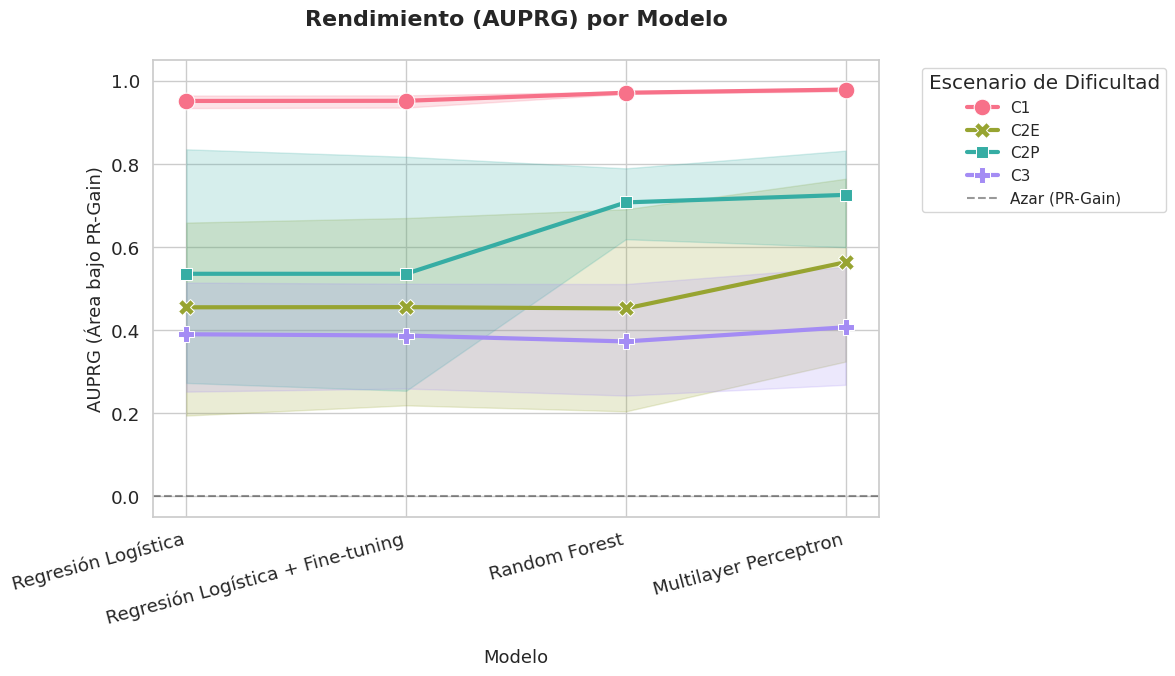

In [43]:
# 1. Filtrar los datos para AUPRG
df_auprg = df_final[["Modelo", "Escenario", "AUPRG"]]

# 2. Configuración estética
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(12, 7))

# 3. Crear la gráfica de líneas
# Agrupación en el eje X, AUPRG en el eje Y, y una línea por Escenario
ax = sns.lineplot(
    data=df_auprg, 
    x="Modelo", 
    y="AUPRG", 
    hue="Escenario", 
    style="Escenario", 
    markers=True, 
    dashes=False, 
    markersize=12, 
    linewidth=3,
    palette="husl", 
    hue_order=["C1", "C2E", "C2P", "C3"] # Forzamos el orden de leyenda
)

# 4. Personalización del gráfico
plt.title("Rendimiento (AUPRG) por Modelo", fontsize=16, weight='bold', pad=25)
plt.xlabel("Modelo", fontsize=13, labelpad=15)
plt.ylabel("AUPRG (Área bajo PR-Gain)", fontsize=13)
plt.ylim(-0.05, 1.05) # Empezamos un poco por debajo de 0 para ver bien la línea de azar

# Rotamos las etiquetas del eje X si son muy largas
plt.xticks(rotation=15, ha='right')

# Línea de referencia en 0.0 (Azar en PR-Gain)
plt.axhline(0.0, ls='--', color='black', alpha=0.4, label="Azar (PR-Gain)")

# Ajustar leyenda
plt.legend(title="Escenario de Dificultad", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig("resumen_auprg_modelos.png", dpi=300)
plt.show()

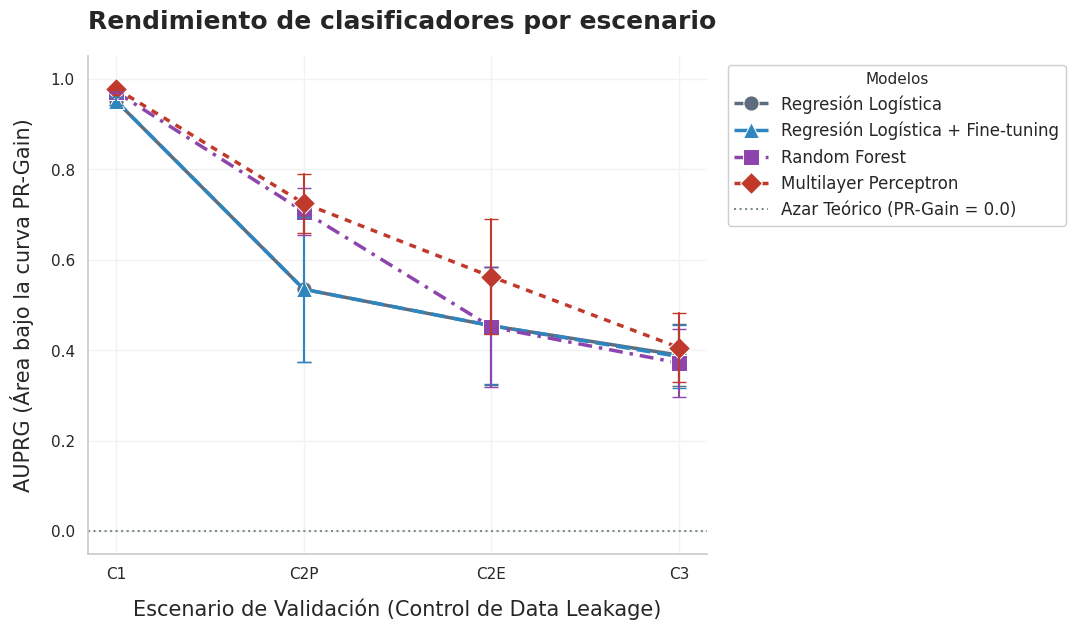

In [44]:
# 1. Asegurar la estructura correcta de los datos
# Nota: Si tu DataFrame tiene los escenarios ordenados al revés, con esto se soluciona
df_auprg = df_final[["Modelo", "Escenario", "AUPRG"]].copy()
df_auprg['Escenario'] = pd.Categorical(
    df_auprg['Escenario'], 
    categories=["C1", "C2P", "C2E", "C3"], 
    ordered=True
)

# 2. Configuración estética global (Estilo académico)
sns.set_theme(style="whitegrid", rc={"grid.color": "#F0F3F4", "grid.linestyle": "-"}, font_scale=1.1)
plt.rcParams["font.family"] = "sans-serif"
plt.figure(figsize=(11, 6.5))

# 3. Mapeos fijos con la paleta académica y tecnológica
colores = {
    "Regresión Logística": "#5D6D7E",
    "Regresión Logística + Fine-tuning": "#2E86C1",
    "Random Forest": "#8E44AD",
    "Multilayer Perceptron": "#C0392B",
}

marcadores = {
    "Regresión Logística": "o",
    "Regresión Logística + Fine-tuning": "^",
    "Random Forest": "s",
    "Multilayer Perceptron": "D",
}

lineas = {
    "Regresión Logística": (1, 0),  # Continua
    "Regresión Logística + Fine-tuning": (4, 2),  # Discontinua corta
    "Random Forest": (4, 2, 1, 2),  # Punto-guion
    "Multilayer Perceptron": (2, 2),  # Punteada densa
}

# 4. Crear la gráfica de líneas refinada
ax = sns.lineplot(
    data=df_auprg,
    x="Escenario",
    y="AUPRG",
    hue="Modelo",
    style="Modelo",
    markers=marcadores,
    dashes=lineas,
    markersize=11,
    linewidth=2.5,
    palette=colores,
    hue_order=["Regresión Logística","Regresión Logística + Fine-tuning","Random Forest","Multilayer Perceptron",],
    errorbar="se",        
    err_style="bars",           
    err_kws={"capsize": 5, "linewidth": 1.5, "zorder": 3},
)

# 5. Personalización avanzada de ejes y etiquetas
plt.title(
    "Rendimiento de clasificadores por escenario",
    fontsize=18,
    weight="bold",
    pad=20,
    loc="left",
)
plt.xlabel("Escenario de Validación (Control de Data Leakage)", fontsize=15, labelpad=12)
plt.ylabel("AUPRG (Área bajo la curva PR-Gain)", fontsize=15, labelpad=12)
plt.tick_params(axis="both", labelsize=11)

# Ajuste estricto de límites del eje Y (0 a 1 para métricas probabilísticas)
plt.ylim(-0.05, 1.05)

# 6. Línea de referencia horizontal impecable para el AZAR
plt.axhline(
    0.0,
    ls=":",
    color="#7F8C8D",
    linewidth=1.5,
    zorder=1,
    label="Azar Teórico (PR-Gain = 0.0)",
)

# 7. Ajustes de la Leyenda (Limpia y fuera del gráfico para que no tape nada)
# Unificamos las leyendas de color y estilo automáticamente usando Matplotlib
handles, labels = ax.get_legend_handles_labels()
plt.legend(
    handles=handles,
    labels=labels,
    title="Modelos",
    title_fontsize=11,
    fontsize=12,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    shadow=False,
    facecolor="white",
    edgecolor="#BDC3C7",
)

# Eliminar bordes innecesarios (Top y Right)
sns.despine(left=False, bottom=False)

# Optimizar distribución de espacios y guardar en alta resolución
plt.tight_layout()
plt.savefig("resumen_auprg_modelos_profesional.png", dpi=300)
plt.show()

## Test de Friedman y Wilcoxon + Bonferroni

Para evaluar si hay diferencias significativas entre los modelos, se aplica el test de Friedman. Es un test análogo a un ANOVA para datos pareados no paramétricos. Se aplicará exclusivamente al nivel C3, comparando los rendimientos de cada iteración de la validación cruzada. Como todos los modelos utilizan los mismos datos se puede aplicar el test.

En el caso de que dé significativo y se rechace la hipótesis nula (H0: no hay diferencias significativas entre los modelos), se hará un test de Wilcoxon, análogo a un t-test para comparar dos tratamientos pareados no paramétricos. Se harán comparaciones entre todas las parejas de modelos. Eso hace un total de 6 tests. Al aumentar el número de tests se corre el riesgo de aumentar el número de falsos positivos, por lo que se aplicará una corrección de Bonferroni para disminuir alpha.

In [50]:
import numpy as np
import pandas as pd
from scipy.stats import friedmanchisquare, wilcoxon

# 1. Extraemos el escenario crítico C3
df_c3_modelos = df_final[df_final["Escenario"] == "C3"].copy()
datos_modelos_folds = {}

for modelo in df_c3_modelos["Modelo"].unique():
    raw_folds = df_c3_modelos[df_c3_modelos["Modelo"] == modelo]["AUPRG_lista"].values[0]
    datos_modelos_folds[modelo] = np.array(raw_folds, dtype=float)
    
    # Ahora sí que debería imprimir: "detectados 15 folds..." (o el número K real de tu CV)
    print(f"Modelo '{modelo}': detectados {len(datos_modelos_folds[modelo])} folds correlacionados en C3.")

print("-" * 80)

modelos_lista = ["Regresión Logística", "Regresión Logística + Fine-tuning", "Random Forest", "Multilayer Perceptron"]
datos_para_friedman = [datos_modelos_folds[mod] for mod in modelos_lista]

# 2. Test Global de Friedman
stat_f, p_val_f = friedmanchisquare(*datos_para_friedman)
print("=== TEST GLOBAL DE FRIEDMAN ===")
print(f"Estadístico Chi-cuadrado (χ²): {stat_f:.4f}")
print(f"Valor-p global del test: {p_val_f:.6f}")

if p_val_f < 0.05:
    print("Resultado: SIGNIFICATIVO (p < 0.05). Procedemos al Post-Hoc.\n")
    print("=" * 80)
    
    # 3. Post-Hoc de Wilcoxon + Bonferroni
    print("=== TEST POST-HOC DE WILCOXON (CORRECCIÓN DE BONFERRONI) ===")
    num_comparaciones = 6  
    alpha_bonferroni = 0.05 / num_comparaciones
    
    resultados_posthoc = []
    for i in range(len(modelos_lista)):
        for j in range(i + 1, len(modelos_lista)):
            mod1, mod2 = modelos_lista[i], modelos_lista[j]
            stat_w, p_val_w = wilcoxon(datos_modelos_folds[mod1], datos_modelos_folds[mod2])
            
            resultados_posthoc.append({
                "Pareja Comparada": f"{mod1}  vs  {mod2}",
                "Valor-p Original": f"{p_val_w:.6f}",
                "Alfa Bonferroni": f"{alpha_bonferroni:.5f}",
                "Significativo": "SÍ" if p_val_w < alpha_bonferroni else "NO"
            })
            
    print(pd.DataFrame(resultados_posthoc).to_string(index=False))
else:
    print("Resultado: NO SIGNIFICATIVO (p >= 0.05). No hay diferencias estadísticas concluyentes.")

Modelo 'Regresión Logística': detectados 15 folds correlacionados en C3.
Modelo 'Regresión Logística + Fine-tuning': detectados 15 folds correlacionados en C3.
Modelo 'Random Forest': detectados 15 folds correlacionados en C3.
Modelo 'Multilayer Perceptron': detectados 15 folds correlacionados en C3.
--------------------------------------------------------------------------------
=== TEST GLOBAL DE FRIEDMAN ===
Estadístico Chi-cuadrado (χ²): 1.9385
Valor-p global del test: 0.585277
Resultado: NO SIGNIFICATIVO (p >= 0.05). No hay diferencias estadísticas concluyentes.


/tmp/ipykernel_310/2007413985.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_310/2007413985.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


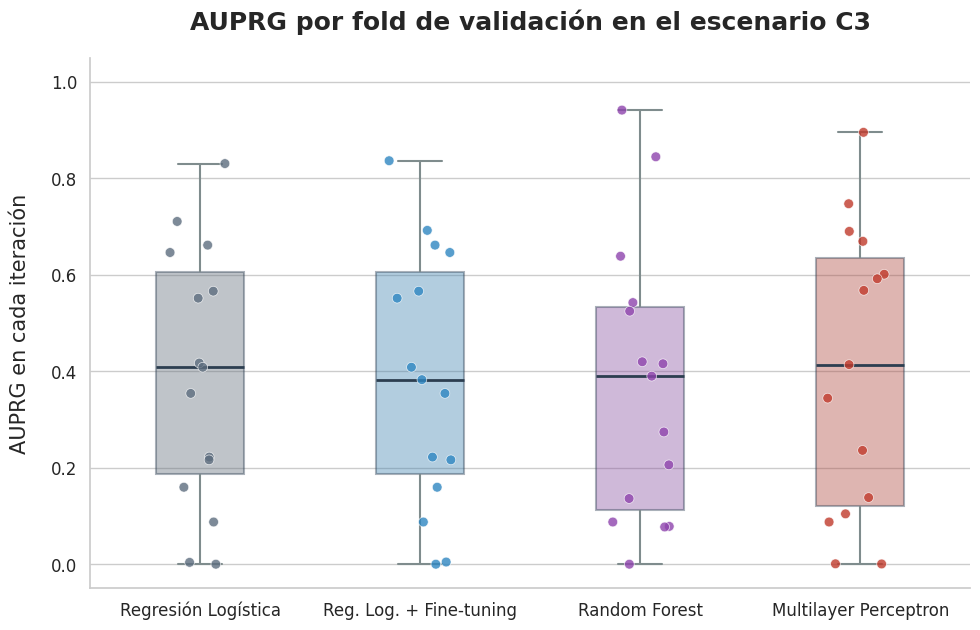

In [75]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Reestructurar los datos de tus 15 folds en formato largo (Long-format) para Seaborn
registros_folds = []
for modelo, folds in datos_modelos_folds.items():
    for i, valor_fold in enumerate(folds):
        registros_folds.append(
            {"Modelo": modelo, "Fold": f"Fold_{i+1}", "AUPRG": valor_fold}
        )

df_boxplot = pd.DataFrame(registros_folds)

# Traducir los nombres exactos para la gráfica final en español
mapeo_nombres = {
    "Regresión Logística": "Regresión Logística",
    "Regresión Logística + Fine-tuning": "Reg. Log. + Fine-tuning",
    "Random Forest": "Random Forest",
    "Multilayer Perceptron": "Multilayer Perceptron",
}
df_boxplot["Modelo"] = df_boxplot["Modelo"].map(mapeo_nombres)

# 2. Configuración estética profesional
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["font.family"] = "sans-serif"
plt.figure(figsize=(10, 6.5))

# Paleta exacta de tu gráfica de líneas para mantener la identidad visual
colores_modelos = [
    "#5D6D7E",  # Gris para Regresión Logística
    "#2E86C1",  # Azul para Regresión Logística + FT
    "#8E44AD",  # Púrpura para Random Forest
    "#C0392B",  # Rojo Óxido para MLP
]

orden_modelos = [
    "Regresión Logística",
    "Reg. Log. + Fine-tuning",
    "Random Forest",
    "Multilayer Perceptron",
]

# 3. Dibujar el Boxplot (Cajas semi-transparentes para ver los puntos detrás)
ax = sns.boxplot(
    data=df_boxplot,
    x="Modelo",
    y="AUPRG",
    order=orden_modelos,
    palette=colores_modelos,
    width=0.4,
    fliersize=0,  # Ocultamos los outliers del boxplot porque los pintaremos con el stripplot
    boxprops=dict(alpha=0.4, edgecolor="#2C3E50", linewidth=1.5),
    medianprops=dict(color="#2C3E50", linewidth=2),
    whiskerprops=dict(color="#7F8C8D", linewidth=1.5),
    capprops=dict(color="#7F8C8D", linewidth=1.5),
)

# 4. Dibujar el Stripplot (Los 15 folds reales como puntos con dispersión horizontal)
sns.stripplot(
    data=df_boxplot,
    x="Modelo",
    y="AUPRG",
    order=orden_modelos,
    palette=colores_modelos,
    size=7,
    jitter=0.15,
    alpha=0.8,
    linewidth=0.5,
    edgecolor="white",
)

# 5. Personalización avanzada estilo editorial
plt.title(
    "AUPRG por fold de validación en el escenario C3",
    fontsize=18,
    weight="bold",
    pad=20,
    loc="center",
)
plt.xlabel("")
plt.ylabel("AUPRG en cada iteración", fontsize=15, labelpad=15)
plt.ylim(-0.05, 1.05)
plt.tick_params(axis="both", labelsize=12)


sns.despine()
plt.tight_layout()
plt.savefig("analisis_estadistico_C3_boxplot.png", dpi=300)
plt.show()